In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r'C:\Users\admin\Documents\My_projects\AQI_project\data\final_integrated_data.csv')
df = df.sort_values("Timestamp").reset_index(drop= True)
df.shape

(29222, 52)

In [3]:
y = df["PM2.5 (µg/m³)"]
y.shape

(29222,)

In [4]:
# Experiment #1 features - CAMS composition

cams_composition = ['co', 'aermr04', 'aermr05', 'aermr06', 'aermr09', 'aermr07', 'aermr10',
       'aermr08', 'no2', 'no', 'go3','so2']

X1 = df[cams_composition]
X1.shape

(29222, 12)

In [5]:
# Experiment #2 features - CAMS composition + meteorology

cams_meteorology = ['q','t','u10', 'v10', 'd2m', 't2m']

X2 = df[cams_composition + cams_meteorology]
X2.shape

(29222, 18)

In [6]:
# EXPERIMENT 1

from sklearn.model_selection import train_test_split
x1_train,x1_test,y_train,y_test = train_test_split(X1,y,test_size=0.20,shuffle= False)  # don't want to shuffle the data , want to test from the last 2 year data
x1_train.shape,x1_test.shape,y_train.shape,y_test.shape

((23377, 12), (5845, 12), (23377,), (5845,))

In [7]:
# EXPERIMENT 2

from sklearn.model_selection import train_test_split
x2_train,x2_test,y2_train,y2_test = train_test_split(X2,y,test_size=0.20,shuffle= False)
x2_train.shape,x2_test.shape,y2_train.shape,y2_test.shape

((23377, 18), (5845, 18), (23377,), (5845,))

In [8]:
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [9]:
# model creation

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (RandomForestRegressor,GradientBoostingRegressor,AdaBoostRegressor)
from xgboost import XGBRegressor

In [10]:
models = {
    "Decision Tree" : DecisionTreeRegressor(random_state=42),
    "Random Forest" : RandomForestRegressor(random_state=42),
    "Gradient Boosting" :GradientBoostingRegressor(random_state=42),
    "AdaBoost" : AdaBoostRegressor(random_state=42),
    "XGBoost" : XGBRegressor(random_state=42)
}

In [11]:
results_exp1 = {}

for name, model in models.items():
    model.fit(x1_train, y_train)
    y_pred = model.predict(x1_test)

    results_exp1[name] = y_pred

In [12]:
results_exp1

{'Decision Tree': array([110.625, 207.75 , 108.   , ..., 295.125, 210.25 , 272.   ],
       shape=(5845,)),
 'Random Forest': array([127.64451292, 165.19349098, 205.3101875 , ..., 230.11369231,
        214.67477778, 266.76742381], shape=(5845,)),
 'Gradient Boosting': array([113.99418883, 137.68858456, 202.71699934, ..., 255.54185274,
        225.57951515, 261.41781894], shape=(5845,)),
 'AdaBoost': array([153.5426892 , 271.81523198, 316.99962789, ..., 429.1993267 ,
        319.07831525, 433.13295474], shape=(5845,)),
 'XGBoost': array([109.337326, 154.53867 , 183.53372 , ..., 247.4404  , 196.04274 ,
        257.83813 ], shape=(5845,), dtype=float32)}

In [13]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

In [14]:
evaluation_exp1 = []

for name, y_pred in results_exp1.items():
    evaluation_exp1.append({
        "Model": name,
        "R2": r2_score(y_test, y_pred),
        "MAE": mean_absolute_error(y_test, y_pred),
        "RMSE": mean_squared_error(y_test, y_pred) ** 0.5
    })

evaluation_exp1 = pd.DataFrame(evaluation_exp1)

evaluation_exp1

,Model,R2,MAE,RMSE
0,Decision Tree,0.154634,67.301269,105.408336
1,Random Forest,0.608984,48.482662,71.688548
2,Gradient Boosting,0.608351,47.872780,71.746541
3,AdaBoost,-0.849173,136.416847,155.898290
4,XGBoost,0.577705,49.017646,74.500769


In [15]:
results_exp2 = {}

for name, model in models.items():
    model.fit(x2_train, y2_train)
    y_pred = model.predict(x2_test)

    results_exp2[name] = y_pred

In [16]:
evaluation_exp2 = []

for name, y_pred in results_exp2.items():
    evaluation_exp2.append({
        "Model": name,
        "R2": r2_score(y2_test, y_pred),
        "MAE": mean_absolute_error(y2_test, y_pred),
        "RMSE": mean_squared_error(y2_test, y_pred) ** 0.5
    })

evaluation_exp2 = pd.DataFrame(evaluation_exp2)

evaluation_exp2

,Model,R2,MAE,RMSE
0,Decision Tree,0.257475,62.558415,98.788884
1,Random Forest,0.645448,46.149061,68.264162
2,Gradient Boosting,0.640197,45.652413,68.767782
3,AdaBoost,-0.772978,139.633544,152.652640
4,XGBoost,0.629806,46.411764,69.753717


In [17]:
comparison = evaluation_exp1.merge(
    evaluation_exp2,
    on="Model",
    suffixes=("_Exp1", "_Exp2")
)

comparison

,Model,R2_Exp1,MAE_Exp1,RMSE_Exp1,R2_Exp2,MAE_Exp2,RMSE_Exp2
0,Decision Tree,0.154634,67.301269,105.408336,0.257475,62.558415,98.788884
1,Random Forest,0.608984,48.482662,71.688548,0.645448,46.149061,68.264162
2,Gradient Boosting,0.608351,47.872780,71.746541,0.640197,45.652413,68.767782
3,AdaBoost,-0.849173,136.416847,155.898290,-0.772978,139.633544,152.652640
4,XGBoost,0.577705,49.017646,74.500769,0.629806,46.411764,69.753717


In [18]:
# Hyperparameter tuning - Gridsearch cv

from sklearn.model_selection import GridSearchCV

In [19]:
param_grids = {
    "Decision Tree": {
        "max_depth":[3,5,10,None],
        "min_samples_split" : [2,5,10],
        "min_samples_leaf" : [1,2,3]
    },
    "Random Forest" : {
        "n_estimators" : [100,200],
        "max_depth" : [2,10,None],
        "min_samples_split" : [2,5],
        "min_samples_leaf" : [1,2]
    },
    "Gradient Boosting" : {
        "n_estimators" : [100,200],
        "learning_rate" : [0.05,0.1],
        "max_depth" : [3,5]
    },
    "AdaBoost" : {
        "n_estimators" : [50,100,200],
        "learning_rate" : [0.01,0.1,1.0]
    },
    "XGBoost" : {
        "n_estimators" : [100,200],
        "learning_rate" : [0.05,0.1],
        "max_depth" : [3,5]
    }
}

In [20]:
tuned_models = {}
best_params = {}

for name, model in models.items():
    print(f"Tuning {name}...")
    
    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grids[name],
        cv=5,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1
    )
    
    grid_search.fit(x2_train, y2_train)
    
    tuned_models[name] = grid_search.best_estimator_
    best_params[name] = grid_search.best_params_
    
    print("Best parameters:", grid_search.best_params_)
    print()

Tuning Decision Tree...
Best parameters: {'max_depth': 5, 'min_samples_leaf': 3, 'min_samples_split': 2}

Tuning Random Forest...
Best parameters: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}

Tuning Gradient Boosting...
Best parameters: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200}

Tuning AdaBoost...
Best parameters: {'learning_rate': 0.01, 'n_estimators': 100}

Tuning XGBoost...
Best parameters: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200}



In [21]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

tuned_evaluation = {}

for name, model in tuned_models.items():
    y_pred = model.predict(x2_test)
    
    r2 = r2_score(y2_test, y_pred)
    mae = mean_absolute_error(y2_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y2_test, y_pred))
    
    tuned_evaluation[name] = {
        "R2": r2,
        "MAE": mae,
        "RMSE": rmse
    }

tuned_evaluation

{'Decision Tree': {'R2': 0.554126884921379,
  'MAE': 49.80524967745477,
  'RMSE': np.float64(76.55230268536113)},
 'Random Forest': {'R2': 0.6529667264564931,
  'MAE': 45.381452146981694,
  'RMSE': np.float64(67.53644152295352)},
 'Gradient Boosting': {'R2': 0.6525246208589445,
  'MAE': 44.85409254854317,
  'RMSE': np.float64(67.57944710430989)},
 'AdaBoost': {'R2': 0.5534206577437422,
  'MAE': 51.87722649566024,
  'RMSE': np.float64(76.61290504485524)},
 'XGBoost': {'R2': 0.6563685402458626,
  'MAE': 44.54059822996432,
  'RMSE': np.float64(67.20461138189425)}}

In [22]:
tuned_df = pd.DataFrame(tuned_evaluation).T.reset_index()

tuned_df.columns = ["Model", "R2_Tuned", "MAE_Tuned", "RMSE_Tuned"]

tuned_df

,Model,R2_Tuned,MAE_Tuned,RMSE_Tuned
0,Decision Tree,0.554127,49.805250,76.552303
1,Random Forest,0.652967,45.381452,67.536442
2,Gradient Boosting,0.652525,44.854093,67.579447
3,AdaBoost,0.553421,51.877226,76.612905
4,XGBoost,0.656369,44.540598,67.204611


In [ ]:
# comparing exp2 before tuning vs after tuning

comparison_tuning = evaluation_exp2.merge(
    tuned_df,
    on="Model"
)

comparison_tuning

,Model,R2,MAE,RMSE,R2_Tuned,MAE_Tuned,RMSE_Tuned
0,Decision Tree,0.257475,62.558415,98.788884,0.554127,49.805250,76.552303
1,Random Forest,0.645448,46.149061,68.264162,0.652967,45.381452,67.536442
2,Gradient Boosting,0.640197,45.652413,68.767782,0.652525,44.854093,67.579447
3,AdaBoost,-0.772978,139.633544,152.652640,0.553421,51.877226,76.612905
4,XGBoost,0.629806,46.411764,69.753717,0.656369,44.540598,67.204611


In [24]:
best_model_name = max(
    tuned_evaluation,
    key=lambda name: tuned_evaluation[name]["R2"]
)

best_model = tuned_models[best_model_name]

print("Best Model:", best_model_name)
print("Best Parameters:", best_params[best_model_name])
print("R2:", tuned_evaluation[best_model_name]["R2"])
print("MAE:", tuned_evaluation[best_model_name]["MAE"])
print("RMSE:", tuned_evaluation[best_model_name]["RMSE"])

Best Model: XGBoost
Best Parameters: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200}
R2: 0.6563685402458626
MAE: 44.54059822996432
RMSE: 67.20461138189425


In [25]:
comparison_tuning["R2_Improvement"] = (
    comparison_tuning["R2_Tuned"] - comparison_tuning["R2"]
)

comparison_tuning["MAE_Improvement"] = (
    comparison_tuning["MAE"] - comparison_tuning["MAE_Tuned"]
)

comparison_tuning["RMSE_Improvement"] = (
    comparison_tuning["RMSE"] - comparison_tuning["RMSE_Tuned"]
)

comparison_tuning

,Model,R2,MAE,RMSE,R2_Tuned,MAE_Tuned,RMSE_Tuned,R2_Improvement,MAE_Improvement,RMSE_Improvement
0,Decision Tree,0.257475,62.558415,98.788884,0.554127,49.805250,76.552303,0.296652,12.753166,22.236581
1,Random Forest,0.645448,46.149061,68.264162,0.652967,45.381452,67.536442,0.007519,0.767608,0.727720
2,Gradient Boosting,0.640197,45.652413,68.767782,0.652525,44.854093,67.579447,0.012328,0.798320,1.188335
3,AdaBoost,-0.772978,139.633544,152.652640,0.553421,51.877226,76.612905,1.326399,87.756318,76.039734
4,XGBoost,0.629806,46.411764,69.753717,0.656369,44.540598,67.204611,0.026563,1.871165,2.549106


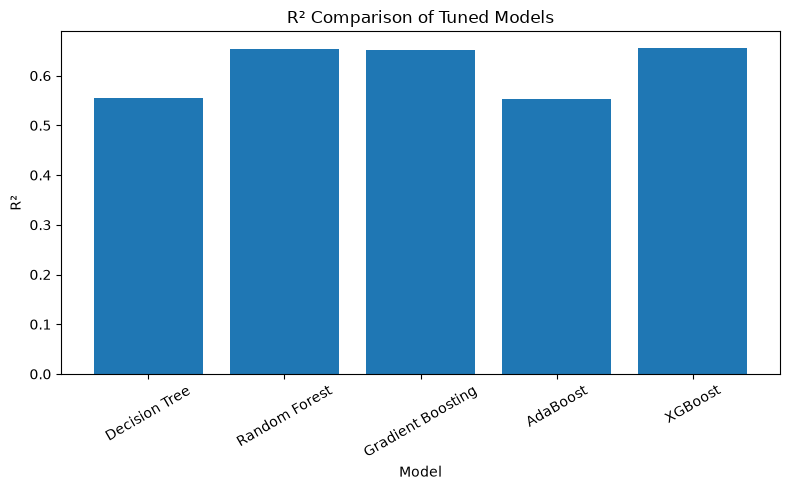

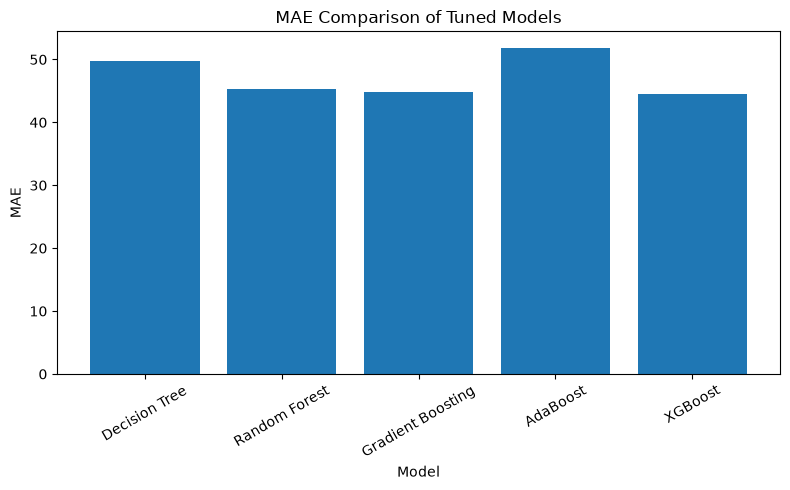

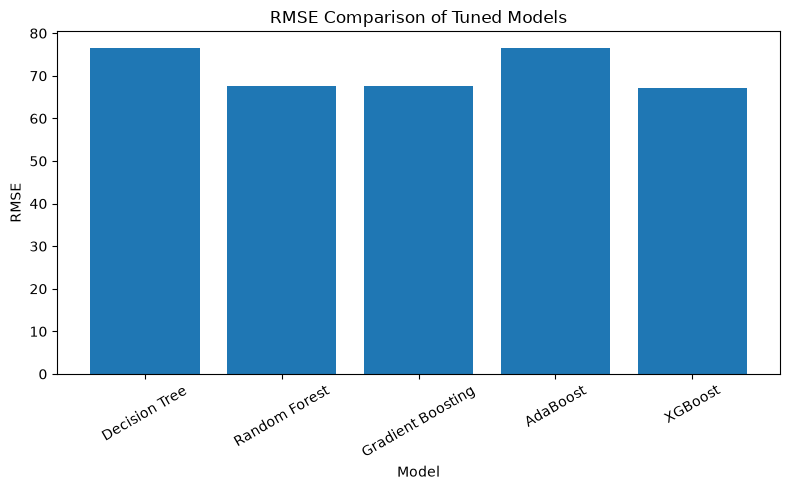

In [26]:
import matplotlib.pyplot as plt

models_tuned = list(tuned_evaluation.keys())
r2_values = [tuned_evaluation[m]["R2"] for m in models_tuned]
mae_values = [tuned_evaluation[m]["MAE"] for m in models_tuned]
rmse_values = [tuned_evaluation[m]["RMSE"] for m in models_tuned]

# R²
plt.figure(figsize=(8, 5))
plt.bar(models_tuned, r2_values)
plt.ylabel("R²")
plt.xlabel("Model")
plt.title("R² Comparison of Tuned Models")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# MAE
plt.figure(figsize=(8, 5))
plt.bar(models_tuned, mae_values)
plt.ylabel("MAE")
plt.xlabel("Model")
plt.title("MAE Comparison of Tuned Models")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# RMSE
plt.figure(figsize=(8, 5))
plt.bar(models_tuned, rmse_values)
plt.ylabel("RMSE")
plt.xlabel("Model")
plt.title("RMSE Comparison of Tuned Models")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [27]:
final_results = pd.DataFrame(tuned_evaluation).T.reset_index()

final_results.columns = ["Model", "R2", "MAE", "RMSE"]

final_results = final_results.sort_values(
    by="R2",
    ascending=False
).reset_index(drop=True)

final_results

,Model,R2,MAE,RMSE
0,XGBoost,0.656369,44.540598,67.204611
1,Random Forest,0.652967,45.381452,67.536442
2,Gradient Boosting,0.652525,44.854093,67.579447
3,Decision Tree,0.554127,49.805250,76.552303
4,AdaBoost,0.553421,51.877226,76.612905
